# IW 6 Project 2: kinematica

Niets tegen de verticale, horizontale of schuine worp. Toch vind ik het zonde om ons onderzoek naar beweging daar al te stoppen, net nu we alle ingrediënten hebben om beweging te beschrijven: positie, snelheid en versnelling. Welkom in de wereld van de complexe bewegingen!

<img src='https://raw.githubusercontent.com/jonasvdw/IW_Teams/main/media/P6_project2_beweging.gif' width='50%'>

In [ ]:
# GEBRUIK DIT MAGISCHE COMMANDO VOOR FIGUREN EN ANIMATIES 
# WEL IN JUPYTER NOTEBOOK, NIET IN TEAMS!

%matplotlib notebook

## 1. Eéndimensionale beweging

Maar vooraleer we complexe bewegingen beschouwen, focussen we op ééndimensionale bewegingen. De meest eenvoudige bewegingen. Bewegingen die met slechts één as voldoende hebben om wiskundig helemaal te kunnen worden beschreven. En om die wiskundig te beschrijven, gebruikt de wiskunde vectortaal. We praten over de positie $\vec{x}$, de snelheid $\vec{v}$ en de versnelling $\vec{a}$, die elk geschreven worden als een component (in de vorm van een wiskundige functie) en één eenheidsvector $\vec{e_x}$:

$$
\begin{cases}
\vec{x} &= x(t) \ \ \vec{e_x} {\quad {\rm \, met \ } x(t) {\rm \ de \ plaatsfunctie}}\\
\vec{v} &= v_x(t) \ \vec{e_x} {\quad {\rm met \ } v_x(t) {\rm \ de \ snelheidscomponent}}\\
\vec{a} &= a_x(t) \ \vec{e_x} {\quad {\rm met \ } a_x(t) {\rm \ de \ versnellingscomponent}}
\end{cases}
$$

### 1.1. De plaatsfunctie $x(t)$

Voor een ééndimensionale beweging wordt de positie $\vec{x}$ bepaald door de plaatsfunctie $x(t)$ enerzijds en de eenheidsvector $\vec{e_x}$ anderzijds. In dit project beschouwen we als voorbeeld de ééndimensionale beweging met plaatsfunctie:

$$\boxed{x(t) = t^4 - 11t^3 + 42t^2 - 64t + 32}$$

en een eenheidsvector naar rechts wijzend zodat de bewegingsas samenvalt met de klassieke horizontale as uit de wiskunde.

<span style="color:#1569C7">**Opdracht 1.**</span> Schrijf de functie `x(t)` die een integer of float als argument krijgt (dat stelt een tijdstip voor), en daaruit de plaatsfunctie op dat tijdstip bepaalt.

**Voorbeeld:**
Bij het uitvoeren van jouw functie met argument 3 seconden:
```python
tijdstip = 3
# maak hier jouw functie x(t) aan
print( 'De plaatsfunctie x(',tijdstip,') =',x(tijdstip))
```
is de uitvoer:
```
De plaatsfunctie x( 3 ) = 2
```

In [4]:
tijdstip = 3
# maak hier jouw functie x(t) aan
def x(t):
    plaatsfunctie = t**4 - 11*t**3 + 42*t**2 - 64*t + 32
    return plaatsfunctie

print( 'De plaatsfunctie x(',tijdstip,') =',x(tijdstip))


De plaatsfunctie x( 3 ) = 2


### 1.2. De snelheidscomponent $v_x(t)$ en versnellingscomponent $a_x(t)$

Naast de positie wordt elke beweging, dus ook de ééndimensionale beweging, gekenmerkt door snelheid $\vec{v}$ en versnelling $\vec{a}$. Beide vectoren worden beschreven met de twee functies snelheidscomponent $v_x(t)$ en versnellingscomponent $a_x(t)$ in combinatie met de steeds naar rechts wijzende eenheidsvector $\vec{e_x}$. Bovendien weten we over de componenten dat:
$$
\begin{cases}
    v_x(t) &= \frac{{\rm d} x(t)}{\rm dt} \\
    a_x(t) &= \frac{{\rm d} v_x(t)}{\rm dt}
\end{cases}
$$

#### a. Numeriek afleiden in wiskunde
Even wat wiskunde oprakelen. We kennen uit het vijfde jaar heel wat rekenregels om afgeleides op te lossen. Ook onze bovenstaande plaatsfunctie $x(t) = t^4 - 11t^3 + 42t^2 - 64t + 32$ afleiden is voor jullie een koud kunstje. Echter, ook al kunnen we dit misschien op een blaadje papier, we willen graag dat de afgeleides door onze pc worden opgelost zodat straks ook voor moeilijkere functies we niets meer zelf hoeven te berekenen. We doen daarvoor beroep op de definitie voor de afgeleide in een punt, als limiet van het differentiequotiënt:
$$
\frac{{\rm d}f(a)}{\rm dx} = \lim_{x \to a} \frac{f(x) - f(a)}{x-a}.
$$

Niets nieuws onder de zon. Er is echter een venijnig addertje in deze definitie, problematisch voor computers: _de limiet_. In theorie (_wiskunde_) is het perfect mogelijk om een willekeurige waarde _x_ op een continue functie geleidelijk te laten naderen tot _a_ om de afgeleide $\frac{df(a)}{dx}$ te berekenen. In de praktijk (_programmeren_) is 'oneindig dicht naderen' onmogelijk. Daarom zijn we hoe dan ook verplicht om de limiet uit de theoretische definitie te halen, met een slechts een benaderende oplossing tot gevolg:
$$
\frac{{\rm d}f(a)}{\rm dx} \approx \frac{f(x) - f(a)}{x-a}.
$$

We kunnen er wel naar streven om de fout zo klein mogelijk te houden door _x_ dicht bij _a_ te kiezen, zoals de limiet insinueerde. Schrijf $x=a+\Delta x$, dan wordt de **numerieke benadering voor de afgeleide in a**:
$$
\boxed{\frac{{\rm d}f(a)}{\rm dx} \approx \frac{f(a+\Delta x) - f(a)}{\Delta x}}.
$$

In onderstaande figuur wordt de theoretische afgeleide samen met de numerieke benadering grafisch weergegeven. Enerzijds wordt de theoretische afgeleide in een punt $(a,f(a))$ gegeven door de richtingscoëfficiënt van de rode raaklijn. Anderzijds is de numerieke benadering als differentiequotiënt de richtingscoëfficiënt van de blauwe rechte door beide punten $(a,f(a))$ en $(a+\Delta x, f(a+\Delta x))$. Deze figuur maakt duidelijk dat de richtingscoëfficiënten van de blauwe rechte de richtingscoëfficiënt van de rode rechte best benadert bij een keuze voor een kleine waarde van $\Delta x$. Een kleine $\Delta x$ is een nodige voorwaarde voor een goede numerieke benadering van de afgeleide in het punt _a_.

<img src='https://raw.githubusercontent.com/jonasvdw/IW_Teams/main/media/P6_project2_numeriekafgeleide.png' width='50%' >

#### b. Numeriek afleiden van $x(t)$ en $v_x(t)$

Toepassend op de kinematica volgt de snelheidscomponent uit de plaatsfunctie door:
$$
\boxed{v_x(t) = \frac{{\rm d} x(t)}{\rm dt} \approx \frac{x(t+\Delta t) - x(t)}{\Delta t}}
$$
en vervolgens de versnellingscomponent uit de snelheidscomponent door:
$$
\boxed{a_x(t) = \frac{{\rm d} v_x(t)}{\rm dt} \approx \frac{v_x(t+\Delta t) - v_x(t)}{\Delta t}}
$$

<span style="color:#1569C7">**Opdracht 2.**</span> Schrijf twee functies `v_x(t,dt)` en `a_x(t,dt)` die beiden twee integers of floats als argumenten krijgen, de eerste is een gegeven tijdstip _t_, het tweede is de $\Delta t$ nodig om de numerieke afgeleide te bepalen. Als resultaat geven jouw functies de snelheidscomponent en de versnellingscomponent op dat tijdstip _t_.

**Voorbeeld:**
Bij het uitvoeren van jouw functies met argumenten 3 en 0,01 seconden:
```python
tijdstip = 3
deltat = 0.01
# maak hier jouw functie v_x(t,dt) aan
# maak hier jouw functie a_x(t,dt) aan
print( 'De snelheidscomponent vx(',tijdstip,') =',round(v_x(tijdstip,deltat),2))
print( 'De versnellingscomponent ax(',tijdstip,') =',round(a_x(tijdstip,deltat),2))
```
is de uitvoer:
```
De snelheidscomponent vx( 3 ) = -1.03
De versnellingscomponent ax( 3 ) = -5.94
```

<span style="color:#1569C7">**Opdracht 3.**</span> Hieronder krijg je de functie `make_figure(t,plaats,snelheid,versnelling)` die de drie grafieken $x(t)$, $v_x(t)$ en $a_x(t)$ onder elkaar plaatst op een gemeenschappelijke horizontale tijdsas. De functie aanvaardt als argumenten vier lijsten met elk precies evenveel elementen.

- Maak een lijst met 500 tijdstippen tussen 0 en 5 seconden;
- Bereken de plaatsfunctie, snelheidscomponent en versnellingscomponent op elk van de tijdstippen (gebruik hiervoor jouw functies uit vorige opdrachten) en sla alles op in lijsten;
- Roep de functie `make_figure(t,plaats,snelheid,versnelling)` aan met de lijsten als argumenten;
- Zet de figuur indien gewenst naar jouw eigen hand.

**Voorbeeld:**
Bij het uitvoeren van jouw code met de gegeven plaatsfunctie $x(t) = t^4 - 11t^3 + 42t^2 - 64t + 32$, is de uitvoer de volgende figuur:

<img src="https://raw.githubusercontent.com/jonasvdw/IW_Teams/main/media/P6_project2_xva.png" width="40%">

In [ ]:
import matplotlib.pyplot as plt

def make_figure(t,plaats,snelheid,versnelling):
    # Maak een figuur met drie subplots onder elkaar, ze delen samen de x-as
    fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    # Bovenste grafiek: x(t)
    axs[0].plot(t, plaats, 'b', label='$x(t)$')
    axs[0].set_ylabel('$x (m)$')
    axs[0].grid(True)

    # Middelste grafiek: v_x(t)
    axs[1].plot(t, snelheid, 'g', label='$v_x(t)$')
    axs[1].set_ylabel('$v_x \ (m/s)$')
    axs[1].grid(True)

    # Onderste grafiek: a_x(t)
    axs[2].plot(t, versnelling, 'r', label='$a_x(t)$')
    axs[2].set_ylabel('$a_x \ (m/s^2)$')
    axs[2].set_xlabel('$t \ (s)$')
    axs[2].grid(True)

    # Zorg ervoor dat de drie grafieken netjes onder elkaar staan
    plt.tight_layout()

    # Toon de plot
    plt.show()

### 1.3. Van componenten naar vectoren: positie $\vec{x}$, snelheid $\vec{v}$ en versnelling $\vec{a}$

Nu nemen we de horizontale as als bewegingsas _x_ waarop een puntmassa beweegt. In de volgende opdracht zul je alvast de code krijgen om deze as te tekenen. Op die as komt nu de puntmassa als een stip, en worden de vectoren $\vec{x}$, $\vec{v}$ en $\vec{a}$ aangeduid. Om een vector te tekenen, gebruiken we de `ax.quiver(xS,yS,x,y)` functie die vier verplichte argumenten verlangt: eerst de coordinaten van het beginpunt (_staart_) van de vector: (xS,yS), daarna de coordinaten van de kop van de vector (x,y), gerekend vanaf de staart! Je kunt dus de coordinaten van de pijlpunt (_kop_) van de vector ten opzichte van de oorsprong berekenen door:
$$
\begin{cases}
xK &= xS + x\\
yK &= yS + y.
\end{cases}
$$

<img src="https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_vector.png?raw=true" width='30%'>

Daarnaast geven we nog heel wat optionele keyword-argumenten mee:
- `angles='xy'` en `scale_units='xy'` zorgen ervoor dat de vector effectief met de xy-coordinaten van de staart en de kop worden gespecifiëerd, zoals uitgelegd hierboven;
- `scale = 1` herschaalt de lengte van de vector. Hier is herschaling niet gewenst, dus we zetten de schaal op 1. Een grotere waarde voor dit argument zorgt voor een kortere vector, maar de richting en zin blijft onveranderd;
- `color = 'blue'` kleurt de vector blauw;
- `label='$\\vec{a}$'` associëert de vector met een label $\vec{a}$, die we later kunnen oplijsten in een legende naast de figuur. Merk op dat de dollartekens \$ bedoeld zijn om wiskundige symbolen te kunnen typen. Een lijst van alle symbolen die je steeds op gelijkaardige manier kunt invoeren, vind je via [deze link](https://www.cmor-faculty.rice.edu/~heinken/latex/symbols.pdf).

Onderstaande code tekent bij wijze van voorbeeld de vector die sterk lijkt op de figuur hierboven. Bestudeer alle elementen van de code goed.

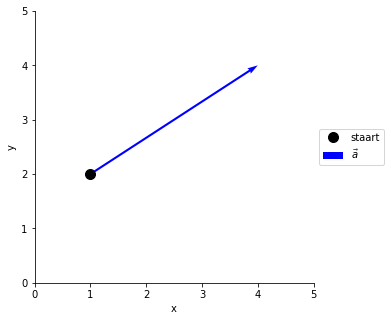

In [3]:
import matplotlib.pyplot as plt

# Staart coordinaten
xS = 1
yS = 2

# Vector coordinaten
x = 3
y = 2


#==============#
#=== FIGUUR ===#
#==============#

fig = plt.figure(figsize=(5,5))
ax = plt.gca()

# Specifiëer afmetingen van de grafiek
ax.set_xlim(0,5)
ax.set_ylim(0,5)

# Zet x en y as labels
ax.set_xlabel('x')
ax.set_ylabel('y')

# Verwijder onnodige elementen uit de grafiek, zodat enkel de x- en y-as over blijven.
ax.spines['right'].set_visible(False) # Verwijder de rechtse rand
ax.spines['top'].set_visible(False)   # Verwijder de bovenrand

# Teken de staart als een zwarte bol
ax.plot(xS,yS, 'ko', markersize=10, label='staart')

# Voeg vector \vec{a} toe
ax.quiver(xS,yS,x,y, angles='xy', scale_units='xy', scale=1, color='blue', label='$\\vec{a}$')

# Voeg een legende toe rechts van de figuur die alle labels oplijst
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Toon de grafiek
plt.show()


<span style="color:#1569C7">**Opdracht 4.**</span> Onderstaand stuk code geeft een figuur met een enkel een x-as. Vervolledig de figuur zodat voor een gegeven tijdstip volgende zaken opgenomen zijn in de figuur:
- als een zwarte stip wordt de locatie van de massa getoond,
- de positie $\vec{x}$ wordt getoond als een blauwe vector van x=0 tot de x-coordinaat van de massa,
- de snelheid $\vec{v}$ wordt getoond als een groene vector aangrijpend op de massa. Om overlap te vermijden, verschuiven we deze vector wat omhoog,
- de versnelling $\vec{a}$ wordt getoond als een rode vector aangrijpend op de massa. Ook deze vector wordt omhoog geschoven zodat er geen vectorpijlen overlappen.

> **TIP**: gebruik de voorbeeldcode hierboven.

**Voorbeeld:**
Bij het uitvoeren van jouw code met de gegeven plaatsfunctie $x(t) = t^4 - 11t^3 + 42t^2 - 64t + 32$ op het tijdstip 3 seconden, is de uitvoer de volgende figuur:

<img src="https://raw.githubusercontent.com/jonasvdw/IW_Teams/main/media/P6_project2_eendim.png" width="65%">

In [ ]:
import matplotlib.pyplot as plt


#==============#
#=== FIGUUR ===#
#==============#

fig = plt.figure(figsize=(10,2))
ax = plt.gca()

# Specifiëer afmetingen van de grafiek
ax.set_xlim(-5,10)
ax.set_ylim(-0.1, 1)

# Zet x as label en verwijder de y as
ax.set_xlabel('x')
ax.get_yaxis().set_visible(False)     # Verwijder de y-as

# Verwijder onnodige elementen uit de grafiek, zodat enkel de x-as over blijft.
ax.spines['left'].set_visible(False)  # Verwijder de linkse rand
ax.spines['right'].set_visible(False) # Verwijder de rechtse rand
ax.spines['top'].set_visible(False)   # Verwijder de bovenrand

# Plaats een fijne verticale lijn op x=0
ax.axvline(0,color='black',linewidth=0.5)

# Toon de grafiek
plt.show()

<!-- ### 1.4. Animatie van de ééndimensionale beweging -->

## 2. Tweedimensionale beweging

Tijd dan om over te gaan naar tweedimensionale bewegingen. Om die wiskundig te beschrijven hebben we een assenstelsel met twee assen (_x_ en _y_) nodig. Opnieuw starten we met de componenten en hun verandering in de tijd om daarna de vectoriële grootheden in volle glorie te aanschouwen. 

$$
\begin{cases}
\vec{r} &= x(t) \ \, \vec{e_x} \ + \, y(t) \ \, \vec{e_y}\\
\vec{v} &= v_x(t) \ \vec{e_x} + v_y(t) \ \vec{e_y} \\
\vec{a} &= a_x(t) \ \vec{e_x} + a_y(t) \ \vec{e_y} 
\end{cases}
$$

### 2.1. De bewegingsvergelijkingen $x(t)$ en $y(t)$
Als voorbeeld onderzoeken we een [lissajous curve](https://en.wikipedia.org/wiki/Lissajous_curve), een tweedimensionale beweging beschreven door de volgende bewegingsvergelijkingen:

$$
\boxed{
\begin{cases}
x(t) &= \cos(3 t) \\
y(t) &= \sin(2 t)
\end{cases}
}
$$

<span style="color:#1569C7">**Opdracht 5.**</span> Schrijf de functie `xy(t)` die een integer of float als argument krijgt (dat stelt het tijdstip _t_ voor) en daaruit beide bewegingsvergelijkingen evalueert op dat tijdstip _t_. Merk op dat de uitvoer van jouw functie een lijst is die zowel de x- als y-component bevat.

**Voorbeeld:**
Bij het uitvoeren van jouw functie met argument 3 seconden:
```python
tijdstip = 3
# maak hier jouw functie xy(t) aan
print( 'Op tijdstip',tijdstip,'s bevindt de puntmassa zich op coordinaat',xy(tijdstip) )
```
is de uitvoer:
```
Op tijdstip 3 s bevindt de puntmassa zich op coordinaat [-0.9111302618846769, -0.27941549819892586]
```

### 2.2. De baan

Bekijken we de 'lissajous' bewegingsvergelijkingen
$$
\begin{cases}
x(t) &= \cos(3 t) \\
y(t) &= \sin(2 t)
\end{cases}
$$
even door een wiskundige bril, dan krijgt _t_ de rol als parameter in de parametervergelijkingen $x(t)$ en $y(t)$. Eliminatie van de tijd in deze vergelijkingen leidt tot de cartesiaanse vorm $y(x)$ of $x(y)$.
In dit voorbeeld kunnen we de parameter _t_ elemineren uit de x(t) vergelijking: $t = \frac{1}{3} {\rm bgcos}(x)$ om die daarna in de y(t) vergelijking te substitueren tot de baanvergelijking $y(x) = \sin(\frac{2}{3} {\rm bgcos}(x))$.

Echter, zo'n parametereleminatie is voor complexe vergelijkingen vaak niet te onderschatten of zelfs niet mogelijk. Daarom schakelen we ook hier opnieuw onze computer in om dit probleem numeriek aan te pakken. Zo hoeven we zelf opnieuw niets te berekenen. Numeriek vinden we de baan van de puntmassa doorheen het xy assenstelsel door herhaaldelijk de (x,y) coordinaten op achtereenvolgende tijdstippen te bepalen en die locaties met elkaar te verbinden.

<span style="color:#1569C7">**Opdracht 6.**</span> Schrijf de functie `baan(t)` die een lijst als argument krijgt. De lijst stelt opeenvolgende tijdstippen voor. Als resultaat geeft de functie een figuur terug met daarin een assenstelsel en de baan beschreven door jouw functie `xy(t)` uit de vorige opdracht.

**Voorbeeld:**
Bij het als volgt uitvoeren van jouw functie:
```python
import numpy as np
tijdstippen = np.linspace(0,2*np.pi,250)
# maak hier jouw functie baan(t) aan
baan(tijdstippen)
```
is de uitvoer de volgende figuur:

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_baan.png?raw=true' width='40%'>

### 2.3. De snelheidscomponenten $v_x(t)$ en $v_y(t)$ en versnellingscomponenten $a_x(t)$ en $a_y(t)$

Net zoals bij de ééndimensionale beweging de afgeleide van de plaatsfunctie $x(t)$ leidt tot de snelheidscomponent $v_x(t)$ en de afgeleide daarvan de versnellingscomponent $a_x(t)$ oplevert, zo gelden dezelfde wiskundige regels voor de componenten in de _y_ richting bij tweedimensionale bewegingen.

Hieronder een kort overzicht van alle numerieke afgeleides:

<div style="width: 100%; font-size: 12px;">
    
|                      x - component                         |                         y - component                      |
|:----------------------------------------------------------:|:----------------------------------------------------------:|
| $x(t)$                                                     | $y(t)$                                                     |
| $v_x(t) \approx \frac{x(t+\Delta t) - x(t)}{\Delta t}$     | $v_y(t) \approx \frac{y(t+\Delta t) - y(t)}{\Delta t}$     |
| $a_x(t) \approx \frac{v_x(t+\Delta t) - v_x(t)}{\Delta t}$ | $a_y(t) \approx \frac{v_y(t+\Delta t) - v_y(t)}{\Delta t}$ |

</div>

<span style="color:#1569C7">**Opdracht 7.**</span> Schrijf twee functies `v_xy(t,dt)` en `a_xy(t,dt)` die beiden twee integers of floats als argumenten krijgen, de eerste is een gegeven tijdstip _t_, het tweede is de $\Delta t$ nodig om de numerieke afgeleide te bepalen. Als resultaat geven jouw functies de x- en y-snelheidscomponenten en de x- en y-versnellingscomponenten op dat tijdstip _t_. Merk op dat de uitvoer van de functies `v_xy(t,dt)` en `a_xy(t,dt)` telkens een lijst is die zowel de x- als y-component bevat, zoals in onderstaand voorbeeld:

**Voorbeeld:**
Bij het uitvoeren van jouw functies met argumenten 0,5 en 0,01 seconden:
```python
tijdstip = 0.5
deltat = 0.01
# maak hier jouw functie v_xy(t,dt) aan
# maak hier jouw functie a_xy(t,dt) aan
print( 'De plaatsfunctie op t=',tijdstip,'is', xy(tijdstip) )
print( 'De snelheidscomponenten zijn'   , v_xy(tijdstip,deltat))
print( 'De versnellingscomponenten zijn', a_xy(tijdstip,deltat))
```
is de uitvoer:
```
De plaatsfunctie op t= 0.5 is [0.0707372016677029, 0.8414709848078965]
De snelheidscomponenten zijn [-2.995219042611187, 1.0637037141466466]
De versnellingscomponenten zijn [-0.36703757211773436, -3.408318474910077]
```

### 2.4. Van componenten naar vectoren: positie $\vec{r}$, snelheid $\vec{v}$ en versnelling $\vec{a}$

Eens alle componenten gekend zijn, kunnen we op een assenstelsel (gedefiniëerd door de eenheidsvectoren $\vec{e_x}$ en $\vec{e_y}$) de positie $\vec{r}$, de snelheid $\vec{v}$ en de versnelling $\vec{a}$ bepalen:

$$
\begin{cases}
\vec{r} &= x(t) \ \, \vec{e_x} \ + \, y(t) \ \, \vec{e_y}\\
\vec{v} &= v_x(t) \ \vec{e_x} + v_y(t) \ \vec{e_y} \\
\vec{a} &= a_x(t) \ \vec{e_x} + a_y(t) \ \vec{e_y} 
\end{cases}
$$

Straks stellen we deze vectoren voor op elk tijdstip (in de vorm van een animatie), maar eerst nemen we één tijdstip onder de loep in een grafiek.

<span style="color:#1569C7">**Opdracht 8.**</span> Creëer een python programma dat de tweedimensionale beweging van een puntmassa voor één gegeven tijdstip toont in een grafiek. In de grafiek zijn volgende zaken aanwezig:
- als een zwarte stip wordt de locatie van de massa getoond,
- de positie $\vec{r}$ wordt getoond als een blauwe vector van de oorsprong tot de massa,
- de snelheid $\vec{v}$ wordt getoond als een groene vector aangrijpend op de massa,
- de versnelling $\vec{a}$ wordt getoond als een rode vector aangrijpend op de massa.

> TIP: Neem zoals in onderstaand voorbeeld de grenzen [-2.5,2.5] voor zowel de x- als de y-as. Je kunt ervoor zorgen dat de snelheidsvector en versnellingsvector binnen de figuur blijven door de vectoren te schalen. Dit doe je door het keyword argument _scale_=2 (voor $\vec{v}$) en _scale_=5 (voor $\vec{a}$) te kiezen in de `ax.quiver()` functie. De verschillende keyword argumenten bestudeerden we eerder in dit project al, neem zeker een kijkje terug!

**Voorbeeld:**
Bij het uitvoeren van jouw code met de gegeven bewegingsvergelijkingen
$$
\begin{cases}
x(t) &= \cos(3 t) \\
y(t) &= \sin(2 t)
\end{cases}
$$
op het tijdstip 3 seconden, is de uitvoer de volgende figuur:

<img src="https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_kinematica-lissajous.png?raw=true" width='50%'>

### 2.5. Animatie van de tweedimensionale beweging

Prima! Je maakte zojuist een figuur die de beweging van de puntmassa op één tijdstip weergeeft. Daarvoor stelden we reeds vast dat de puntmassa voortdurend van positie verandert, samengevat door de _baan_ van de beweging. Ook de snelheid en de versnelling van de puntmassa veranderen voortdurend. In onderstaande opdracht verduidelijken we die voortdurende verandering door de figuur om te vormen tot een **animatie** waarbij ook de tijd loopt.

Voor je zelf de animatie van de tweedimensionale beweging (lissajous) opstelt, geef ik eerst enkele voorbeelden waar je straks voor de opdracht inspiratie kunt uit halen. De voorbeelden zijn:
- animatie van een bewegend punt
- animatie van een curve
- animatie van een vector
- animatie van tekst op/rond de grafiek

> **BELANGRIJK!** Helaas heeft Teams (voorlopig?) moeite met het tonen van animaties. Het is voor deze opdracht daarom noodzakelijk om OFFLINE te werken in Jupyter Notebook (geïnstalleerd via de [Anaconda verdeler](https://www.anaconda.com/download)). Download hiervoor het _ipynb_ bestand vanuit de Teams opdracht. Onderstaande voorbeelden kun je dan op jouw computer in Jupyter Notebook uitvoeren en het resultaat bestuderen. Als je daarna zelf jouw animatiecode schrijft in Jupyter Notebook, vergeet dan niet om jouw cel code te kopiëren naar de overeenkomstige cel in Teams! 

> Om animaties in Jupyter Notebook te kunnen maken, moet jouw code starten met het commando `%matplotlib notebook` bovenaan jouw programma (nog bóven de import statements). Dit zul je al snel in onderstaande voorbeelden opmerken. Merk op dat dit commando niet werkt in Teams.


#### 2.5.1. Animatie van een bewegend punt

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_animatie-bewegendpunt.gif?raw=true' width='50%'>

In [ ]:
#======================================#
#=== ANIMATIE VAN EEN BEWEGEND PUNT ===#
#======================================#

%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Maak plaats voor de figuur en plaats assenstelsel
fig = plt.figure()
ax = plt.gca()

# Zorg voor de aanmaak van een punt, ook al heeft die nog geen positie (let op de lege lijsten!)
# Hier kun je alle vaste eigenschappen van het punt bepalen.
# Zo bijvoorbeeld: het argument 'ko' zal het punt als een zwarte stip laten weergeven ('k' is de afkorting voor 'black' en 'o' is het symbool voor een ronde stip)
point, = ax.plot([], [], 'ko', markersize=10, label='punt P')

def init():
    # INITIALISATIE VAN DE ANIMATIE
    point.set_data(0,0)   # Oorspronkelijk staat het punt op de oorsprong
    return point

def update(t):
    # WAT VERANDERT ER BIJ ELKE NIEUWE TIJDSTAP?
    xco = t**2-3*t
    yco = -2*t
    point.set_data(xco,yco)  # Verplaats het punt P elke tijdstap
    return point

# Maak een animatie
timesteps = np.linspace(0,5, 50) # We maken 50 tijdstappen tussen 0 en 5 seconden
ani = FuncAnimation(fig, update, frames=timesteps, init_func=init, blit=True, interval=50)

# Voeg de as labels toe en specifiëer de grenzen van beide assen
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

# Voeg een legende toe, voeg grijze grid-lijnen toe en zorg voor een gelijke x- en y- ijking van de assen
plt.legend()
plt.grid(True)
ax.set_aspect('equal', 'box')

# Toon de animatie
plt.show()

#### 2.5.2. Animatie van een curve

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_animatie-bewegendecurve.gif?raw=true' width='50%'>

In [ ]:
#==============================#
#=== ANIMATIE VAN EEN CURVE ===#
#==============================#

%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Maak plaats voor de figuur en plaats assenstelsel
fig = plt.figure()
ax = plt.gca()

# Zorg voor de aanmaak van een curve, ook al heeft die nog geen positie (let op de lege lijsten!)
# Hier kun je alle vaste eigenschappen van de curve bepalen.
# Zo bijvoorbeeld: het argument 'r-' zal de curve een rode doorlopende lijn maken
curve, = ax.plot([], [], 'r-', linewidth=0.5)

# Lijsten om de curve bij te houden
x_data, y_data = [], []

def init():
    # INITIALISATIE VAN DE ANIMATIE
    curve.set_data(0,0)   # Oorspronkelijk staat het punt op de oorsprong
    return curve

def update(t):
    # WAT VERANDERT ER BIJ ELKE NIEUWE TIJDSTAP?
    xco = t
    yco = np.sin(t)
    
    # Voeg de huidige positie toe aan de lijsten voor de curve
    x_data.append(xco)
    y_data.append(yco)
    
    curve.set_data(x_data,y_data)  # update de curve elke tijdstap
    return curve

# Maak een animatie
timesteps = np.linspace(-4*np.pi,4*np.pi, 100) # We maken 100 tijdstappen tussen -4pi en 4pi seconden
ani = FuncAnimation(fig, update, frames=timesteps, init_func=init, blit=True, interval=50)

# Voeg de as labels toe en specifiëer de grenzen van beide assen
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

# Voeg grijze grid-lijnen toe
plt.grid(True)

# Toon de animatie
plt.show()

#### 2.5.3. Animatie van een bewegende vector

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_animatie-bewegendevector.gif?raw=true' width='50%'>

In [ ]:
#===============================#
#=== ANIMATIE VAN EEN VECTOR ===#
#===============================#

%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Maak plaats voor de figuur en plaats assenstelsel
fig = plt.figure()
ax = plt.gca()

# Zorg voor de aanmaak van een vector, ook al heeft die nog een lengte 0
# Hier kun je alle vaste eigenschappen van de vector bepalen, zoals we eerder al bestudeerden.
vector_a = ax.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='blue', label='$\\vec{a}$')

def init():
    # INITIALISATIE VAN DE ANIMATIE
    vector_a.set_offsets([0,0])  # Oorspronkelijke staart van de vector
    vector_a.set_UVC(0, 0)       # Oorspronkelijke kop van de vector, gerekend vanaf de staart
    return vector_a

def update(t):
    # WAT VERANDERT ER BIJ ELKE NIEUWE TIJDSTAP?
    xstaart = t          # x-coordinaat van de staart verandert lineair in de tijd
    ystaart = np.sin(t)  # y-coordinaat van de staart verandert sinusoidaal in de tijd
    
    xkop = 0             # x-coordinaat van de vector verandert niet in de tijd
    ykop = 4*np.sin(t)   # y-coordinaat van de vector verandert sinusoidaal in de tijd
    
    vector_a.set_offsets([xstaart, ystaart])  # Verplaats de staart van de vector
    vector_a.set_UVC(xkop,ykop)               # update de vector elke tijdstap
    return vector_a

# Maak een animatie
timesteps = np.linspace(-4*np.pi,4*np.pi, 100) # We maken 100 tijdstappen tussen -4pi en 4pi seconden
ani = FuncAnimation(fig, update, frames=timesteps, init_func=init, blit=True, interval=50)

# Voeg de as labels toe en specifiëer de grenzen van beide assen
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

# Voeg grijze grid-lijnen toe
plt.grid(True)

# Toon de animatie
plt.show()

#### 2.5.4. Animatie van veranderende tekst

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_animatie-bewegendetekst.gif?raw=true' width='50%'>

In [ ]:
#=============================================#
#=== ANIMATIE VAN TEKST OP/ROND DE GRAFIEK ===#
#=============================================#

%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Maak plaats voor de figuur en plaats assenstelsel
fig = plt.figure()
ax = plt.gca()

# Een vaste curve op de grafiek
ax.plot([-5,0,5],[3,0,7])

def init():
    # INITIALISATIE VAN DE ANIMATIE
    ax.set_title('t = 0.00 s')  # Oorspronkelijke titel van de grafiek
    # de titel hoeft niet geretourneerd te worden

def update(t):
    # WAT VERANDERT ER BIJ ELKE NIEUWE TIJDSTAP?
    ax.set_title('t = '+str(round(t,2))+' s')
    # de titel hoeft niet geretourneerd te worden

# Maak een animatie
timesteps = np.linspace(0,5, 50) # We maken 50 tijdstappen tussen 0 en 5 seconden
ani = FuncAnimation(fig, update, frames=timesteps, init_func=init, blit=True, interval=50)

# Voeg de as labels toe en specifiëer de grenzen van beide assen
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

# Voeg grijze grid-lijnen toe
plt.grid(True)

# Toon de animatie
plt.show()

#### 2.5.5. Opslaan van een animatie als .gif bestand

Wil je jouw animatie op jouw computer opslaan in plaats van altijd jouw code te moeten uitvoeren, dat kan. Gebruik daarvoor onderstaande code. Het import statement komt (uiteraard) helemaal bovenaan jouw code, het opslaan zelf gebeurt vlak voor de `plt.show()` regel. Merk op dat het `ani` object moet bestaand, dit wordt aangemaakt door de functie `FuncAnimation()` eerder in de code. Het bestand wordt opgeslagen in dezelfde map waarin je momenteel aan het werken bent (lokaal op jouw computer via Jupyter Notebook, dus niet in Teams!). De naam van het bestand kun je zelf kiezen en ingeven als string. Het aantal _frames per second_ kun je specifiëren met het _fps_ argument. _fps_=10 is vaak een goede keuze.

In [ ]:
from matplotlib.animation import PillowWriter

writergif = PillowWriter(fps=10)
ani.save("naam_van_de_animatie.gif", writer=writergif)

<span style="color:#1569C7">**Opdracht 9.**</span> Schrijf een python programma dat de tweedimensionale beweging van een puntmassa voor een gegeven lijst opeenvolgende tijdstippen als een animatie toont in een grafiek. In de animatie zijn volgende zaken aanwezig:
- als een zwarte stip wordt de locatie van de massa getoond,
- de positie $\vec{r}$ wordt getoond als een blauwe vector van de oorsprong tot de massa,
- de snelheid $\vec{v}$ wordt getoond als een groene vector aangrijpend op de massa,
- de versnelling $\vec{a}$ wordt getoond als een rode vector aangrijpend op de massa,
- de baan wordt getekend waar de massa al is gepasseerd,
- de grafiektitel houdt de tijd _t_ bij,
- sla het bestand lokaal op jouw computer op als een .gif bestand.

> <span style="color:#1569C7">Zoals eerder opgemerkt, zul je voor deze opdracht moeten werken in Jupyter Notebook. Download het _.ipynb_ bestand vanuit de Teams opdracht en open het bestand via Jupyter Notebook. **Vergeet niet om jouw code te kopiëren naar de overeenkomstige cel in Teams en dit in te dienen!**</span>

> **TIP**: Voor deze opdracht komt het er op neer om alle informatie uit bovenstaande voorbeelden te combineren!

**Voorbeeld:**
Bij het uitvoeren van jouw code met de gegeven bewegingsvergelijkingen
$$
\begin{cases}
x(t) &= \cos(3 t) \\
y(t) &= \sin(2 t)
\end{cases}
$$

voor 100 tijdstippen tussen 0 en 2$\pi$ seconden, is de uitvoer de volgende animatie:

<img src="https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_kinematica-lissajous.gif?raw=true" width='50%'>


### 2.6. Uitbreiding: lissajous banen

Het voorbeeld dat we hierboven beschreven
$$
\begin{cases}
x(t) &= \cos(3 t) \\
y(t) &= \sin(2 t)
\end{cases}
$$

is slechts één mogelijke [Lissajous figuur](https://en.wikipedia.org/wiki/Lissajous_curve). Alle andere worden steeds gevormd door de x- en y-component die met een bepaalde frequentie trillen (x: links en rechts en y: op en neer). De frequentie wordt gespecifiëerd door het getal voor de tijdsvariabele _t_ binnen de _cos_ en _sin_ functies.

In de animatie hieronder vind je enkele voorbeelden. Merk hierbij op dat de bovenste rij cirkels de $x(t)$ component voorstelt door een punt op een cirkel te laten draaien. Dit is slechts een voorstelling. Om de échte $x(t)$ component daarin te zien, moeten we een loodrechte projectie van dat draaiende punt op de horizontale _x_ as maken. De resulterende links-rechts beweging wordt voorgesteld door de lange grijze verticale lijen. Die 'cirkelvoorstelling' van $x(t)$ is louter bedoeld om snel de verschillende frequenties te kunnen lezen. De **1**-cirkel is de referentie, in een bepaalde tijd gaat het punt één keer rond op de cirkel. In de **2**-cirkel gaat het punt in dezelfde tijd precies twee keer rond, in de **3**-cirkel precies drie keer... 

Dezelfde redenering wordt gemaakt om de $y(t)$ component te vormen. Hierbij is een loodrechte projectie van het op een cirkel draaiende punt op de verticale _y_ as nodig. Ook hier stellen de getallen de frequenties voor. Trouwens, vind je ons voorbeeld terug?

<img src='https://github.com/jonasvdw/IW_Teams/blob/main/media/P6_project2_lissajous-wiki.gif?raw=true' width='30%'>



<span style="color:#1569C7">**Opdracht 10.**</span> Maak jouw eindprogramma. Jouw programma vraagt de gebruiker om de `x-frequentie` en `y-frequentie` van de lissajous figuur. Daarmee gaat jouw programma aan het werk. Als resultaat is de overeenkomstige animatie opgeslagen en verschijnt er de boodschap:
```
De lissajous animatie met x-frequentie 2 en y-frequentie 3 is opgeslagen als: lissajous_x2y3.gif.
```

<span style="color:#1569C7">**Opdracht 11.**</span> Nu is het aan jou. Stel zelf een vraag op die interessant lijkt over Lissajous figuren. Het kan gaan over een figuur, over een animatie... Je bent volledig vrij. Stel jouw vraag aan mij - dan oordeel ik of jouw vraag haalbaar is. Schrijf daarna een programma dat een antwoord biedt op jouw vraag.